In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Setting style for visual appeal
sns.set_theme(style="whitegrid")

# Task 1: Load the data
df = pd.read_csv('../data/q2_customers.csv')

# Selecting the specific features mentioned in the prompt
features = ['age', 'annual_spend', 'visits_per_month', 'basket_size', 
            'days_since_last_visit', 'num_categories_purchased']
X = df[features]

# Preview to ensure it loaded correctly
print(f"Dataset loaded with {df.shape[0]} customers.")
df.head()

Dataset loaded with 500 customers.


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [2]:
# Initializing the scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features scaled successfully.")

Features scaled successfully.


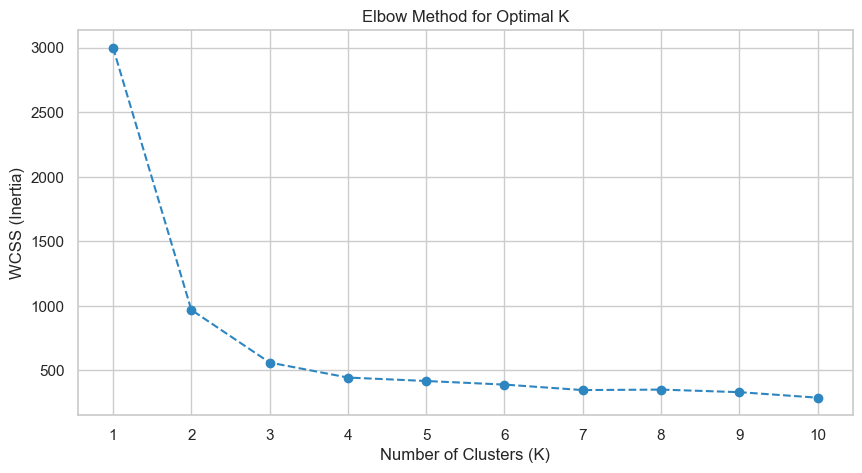

In [3]:
# Task 2: Elbow Method to find the optimal number of clusters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plotting the results
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', color='#2E86C1', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, 11))
plt.show()

In [4]:
# Initializing K-Means with the chosen K=4
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Creating a readable dataframe for centroids
# We inverse transform to see the real-world values instead of scaled ones
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroid_df = pd.DataFrame(centroids, columns=features)
centroid_df.index.name = 'Cluster'

print("Cluster Centroids (Real-world values):")
centroid_df

Cluster Centroids (Real-world values):


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
Cluster,,,,,,
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,57.134146,89778.451220,2.463415,5345.500000,147.060976,7.524390
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242
3,56.409639,89052.614458,2.590361,5713.361446,64.156627,7.506024


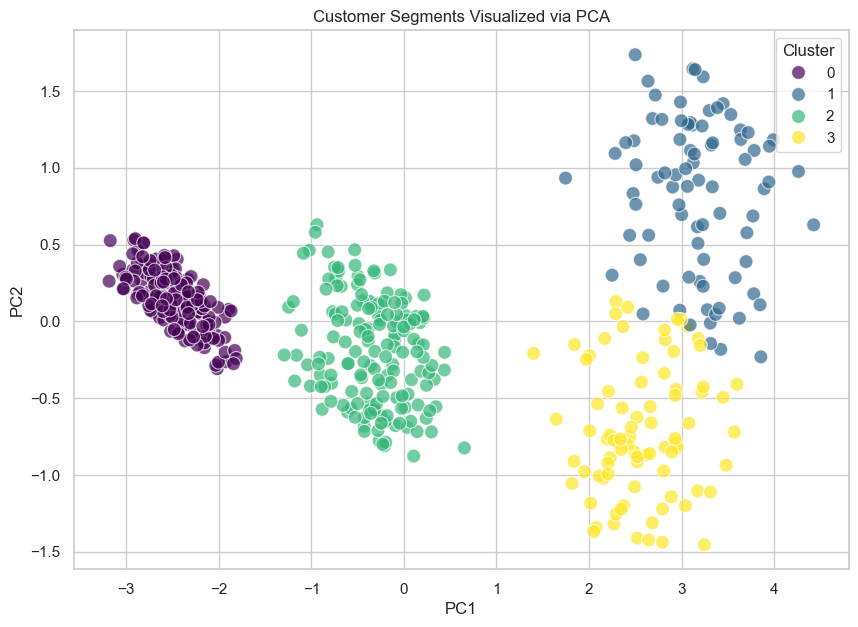

Total Variance Captured by PC1 & PC2: 89.13%


In [5]:
# Task 4: Dimensionality Reduction with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Adding PCA results to the main dataframe
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

# Task 5: Cluster Visualization
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=df, palette='viridis', s=100, alpha=0.7)
plt.title('Customer Segments Visualized via PCA')
plt.legend(title='Cluster', loc='upper right')
plt.show()

# Printing Explained Variance
print(f"Total Variance Captured by PC1 & PC2: {sum(pca.explained_variance_ratio_)*100:.2f}%")